In [11]:
import os
os.environ["JAX_PLATFORMS"] = 'cpu'
import jax.numpy as jnp
import jax 
import numpy as np
from utils import (
                  syn_group_ids_path,
                  collect_data,
                  torch_to_jax,
                  flatten_tokens_features,
                  depths,
                  reduce_list_half_preserve_extremes,
                  remove_syn_group_averages,
                  )
from geometry import normalized_L2_distance
from datapaths import * 
import matplotlib.pyplot as plt


In [23]:
min_token_length = 6
n_tokens = min_token_length
n_files = 21
model_name = 'qwen7b'
precision = 32
data_var = 'syn'
avg_tokens = 0

input_path_A = input_paths['english'][model_name]['matching']['0'][data_var]


In [24]:
all_activations_A = collect_data(input_path_A, 
            min_token_length, 
            n_files,
            model_name,
            avg_tokens,
            )

qwen7b dtype: torch.bfloat16


Collect File: 100%|██████████| 21/21 [00:29<00:00,  1.41s/it]


all_hidden_states["layer_0"].shape=torch.Size([2098, 6, 3584])
importing took 0.5202163179715474 m


In [36]:
space_index = 'A'
global_center_flag = 1
act_A = {}
centers = {}
global_centers = {}
layers_A = np.array([1],dtype=int) # reduce_list_half_preserve_extremes(np.arange(1,depths[model_name]+1,dtype=int))

for layer_A in layers_A:
    activations_A = all_activations_A[f"layer_{layer_A}"]
    act_A[str(layer_A)] = torch_to_jax(activations_A[:,-n_tokens:,:],precision)
    act_A[str(layer_A)] = flatten_tokens_features(act_A[str(layer_A)])
    if global_center_flag:
        global_centers[str(layer_A)] = jnp.mean(act_A[str(layer_A)],axis=0)
        act_A[str(layer_A)] = act_A[str(layer_A)] - jnp.broadcast_to(global_centers[str(layer_A)],act_A[str(layer_A)].shape)
    else:
        global_centers[str(layer_A)] = None
    
    # syntax_centers
    centers_folder = f"/home/acevedo/syn-sem/results/global_centering_0/spaces_AB/similarity_fn_normalized_L2_distance/precision_32/language_english/data_var_syn/modelA_qwen7b/modelB_qwen7b/match_var_matching/n_files_21/min_token_length_{min_token_length}/similarities/centers_syn/Nbits_0/n_tokens_{n_tokens}/avg_tokens_0/batch_shuffle_0/layer_A_{layer_A}/layer_B_{layer_A}/"
    centers[str(layer_A)] = jnp.array(np.load(os.path.join(centers_folder, f'syn_centers_{space_index}.npy'))).astype(jnp.float32) #(num_groups,E)
    
    if global_center_flag: # global centering syntax_centers...
        centers[str(layer_A)] = centers[str(layer_A)] - jnp.broadcast_to(global_centers[str(layer_A)],centers[str(layer_A)].shape)
    # all_indices = jnp.array(np.loadtxt(centers_folder + f'syn_all_indices.txt',dtype=int),dtype=jnp.int32)
    # all_counts = jnp.array(np.loadtxt(centers_folder + f'syn_all_counts.txt',dtype=int),dtype=jnp.int32)

print(f'{act_A[str(layer_A)].shape=}')
print(f'{centers[str(layer_A)].shape=}')

act_A[str(layer_A)].shape=(2098, 21504)
centers[str(layer_A)].shape=(96, 21504)


overlaps.mean()=Array(-0.00389251, dtype=float32)
Distribution of overlaps between all centers


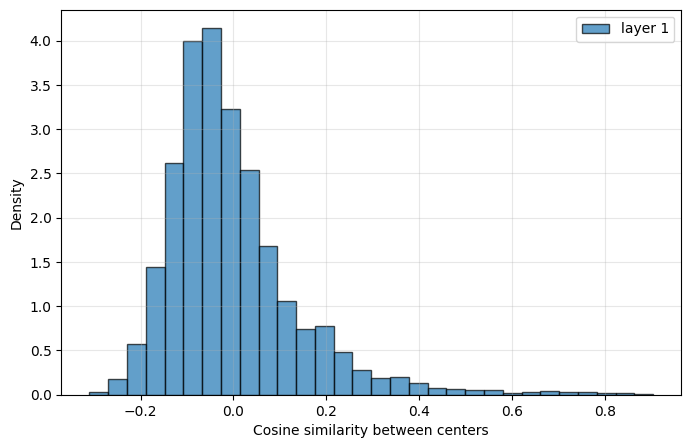

In [37]:
### OVERLAPS BETWEEN ALL CENTERS

import itertools

plt.figure(figsize=(8,5))

for layer_A in layers_A:

  # Normalize all centers
  normed_centers = centers[str(layer_A)] / jnp.linalg.norm(centers[str(layer_A)], axis=1, keepdims=True)  # shape: (n_centers, dim)

  # Compute all pairwise overlaps (excluding self-overlaps)
  n_centers = normed_centers.shape[0]
  overlaps = []
  for i, j in itertools.combinations(range(n_centers), 2):
      overlaps.append(jnp.dot(normed_centers[i], normed_centers[j]))
  overlaps = jnp.array(overlaps)
  print(f'{overlaps.mean()=}')

  # Plot histogram
  plt.hist(overlaps, bins=30, edgecolor='black', alpha=0.7, density=True, label=f'layer {layer_A}')
plt.xlabel('Cosine similarity between centers')
plt.ylabel('Density')
print(f'Distribution of overlaps between all centers')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


acts.shape = (2098, 21504)
centers.shape = (96, 21504)
group_ids.shape = (2098,)
unique groups in data = 96
number of centers = 96
Largest group_id=59 (76 samples)
Second largest group_id=87 (71 samples)


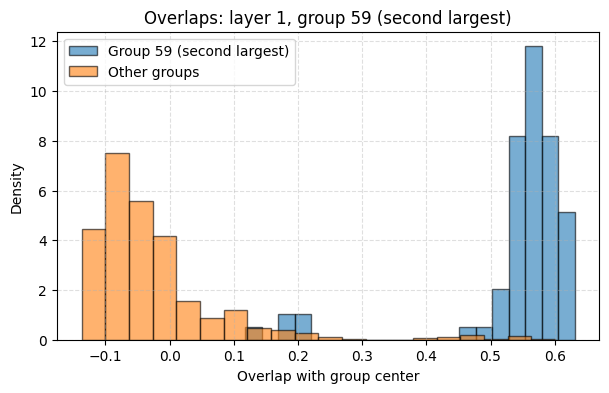

In [40]:
layer_A = layers_A[0]
bins = 20 

# activations: (N, E)
acts = act_A[str(layer_A)]
print(f"acts.shape = {acts.shape}")

# centers: (G, E)
all_centers = centers[str(layer_A)]
print(f"centers.shape = {all_centers.shape}")

# load group IDs
group_ids = jnp.array(np.loadtxt(syn_group_ids_path, dtype=int))
print(f"group_ids.shape = {group_ids.shape}")

# sanity check
unique_groups, counts = jnp.unique(group_ids, return_counts=True)
print(f"unique groups in data = {len(unique_groups)}")
print(f"number of centers = {all_centers.shape[0]}")
assert len(unique_groups) == all_centers.shape[0], "Mismatch: groups vs centers!"

# sort groups by size (descending)
sorted_idx = jnp.argsort(-counts)
largest_group = int(unique_groups[sorted_idx[0]])
second_largest_group = int(unique_groups[sorted_idx[1]])
print(f"Largest group_id={largest_group} ({counts[sorted_idx[0]]} samples)")
print(f"Second largest group_id={second_largest_group} ({counts[sorted_idx[1]]} samples)")

# pick the second largest
center_id = largest_group
center = all_centers[center_id]

# normalize
acts_normed = acts / jnp.linalg.norm(acts, axis=1, keepdims=True)
center_normed = center / jnp.linalg.norm(center)

# overlaps
overlaps = acts_normed @ center_normed

# split by group membership
same_mask = (group_ids == center_id)
diff_mask = ~same_mask

same_overlaps = np.array(overlaps[same_mask])
diff_overlaps = np.array(overlaps[diff_mask])

# plot
plt.figure(figsize=(7, 4))
plt.hist(same_overlaps, bins=bins, alpha=0.6, color="tab:blue", edgecolor="black",
         density=True, label=f"Group {center_id} (second largest)")
plt.hist(diff_overlaps, bins=bins, alpha=0.6, color="tab:orange", edgecolor="black",
         density=True, label="Other groups")
plt.xlabel("Overlap with group center")
plt.ylabel("Density")
plt.title(f"Overlaps: layer {layer_A}, group {center_id} (second largest)")
plt.legend()
plt.grid(alpha=0.4, linestyle="--")
plt.show()


Using group 59 with 76 samples


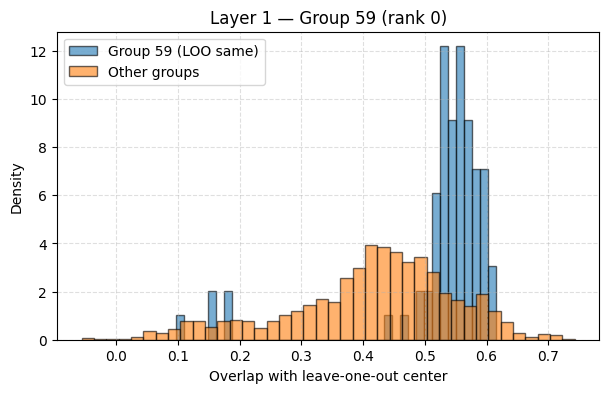

In [41]:
def plot_overlaps_with_LOO(layer_A, centers, act_A, syn_group_ids_path, group_rank=1):
    """
    Plot overlaps between activations and leave-one-out (LOO) centers.
    
    Args:
        layer_A: int, layer index
        centers: dict[str, jnp.ndarray], precomputed group centers (vanilla means)
        act_A: dict[str, jnp.ndarray], activations
        syn_group_ids_path: str, path to file with group IDs
        group_rank: int, which group to use (0 = largest, 1 = second largest, etc.)
    """
    # activations: (N, E)
    acts = act_A[str(layer_A)]

    # group centers: (G, E)
    group_centers = centers[str(layer_A)]

    # group IDs (N,)
    group_ids = jnp.array(np.loadtxt(syn_group_ids_path, dtype=int))

    # sanity check
    unique_groups, counts = jnp.unique(group_ids, return_counts=True)
    assert len(unique_groups) == group_centers.shape[0], "Mismatch: groups vs centers!"

    # pick group by size rank
    sorted_idx = jnp.argsort(-counts)
    center_id = int(unique_groups[sorted_idx[group_rank]])
    print(f"Using group {center_id} with {counts[sorted_idx[group_rank]]} samples")

    # map group counts and means to each sample
    counts_for_samples = counts[jnp.searchsorted(unique_groups, group_ids)]
    means_for_samples = group_centers[group_ids]

    # compute leave-one-out centers
    loo_centers = (counts_for_samples[:, None] * means_for_samples - acts) / (counts_for_samples[:, None] - 1)

    # normalize
    acts_normed = acts / jnp.linalg.norm(acts, axis=1, keepdims=True)
    loo_normed = loo_centers / jnp.linalg.norm(loo_centers, axis=1, keepdims=True)

    # overlaps (sample with its own LOO center)
    overlaps = jnp.sum(acts_normed * loo_normed, axis=1)

    # split by same vs different group
    same_mask = (group_ids == center_id)
    diff_mask = ~same_mask

    same_overlaps = np.array(overlaps[same_mask])
    diff_overlaps = np.array(overlaps[diff_mask])

    # plot
    plt.figure(figsize=(7, 4))
    plt.hist(same_overlaps, bins=40, alpha=0.6, color="tab:blue", edgecolor="black",
             density=True, label=f"Group {center_id} (LOO same)")
    plt.hist(diff_overlaps, bins=40, alpha=0.6, color="tab:orange", edgecolor="black",
             density=True, label="Other groups")
    plt.xlabel("Overlap with leave-one-out center")
    plt.ylabel("Density")
    plt.title(f"Layer {layer_A} — Group {center_id} (rank {group_rank})")
    plt.legend()
    plt.grid(alpha=0.4, linestyle="--")
    plt.show()


plot_overlaps_with_LOO(layer_A=1,
                       centers=centers,
                       act_A=act_A,
                       syn_group_ids_path=syn_group_ids_path,
                       group_rank=0)

